# Dacon 고객 대출등급 분류 해커톤

link : https://dacon.io/competitions/official/236214/overview/description

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

train_df = pd.read_csv('C:/Users/USER/Desktop/TIL_new/competitions/Dacon_customer_loan_level/train.csv')
test_df = pd.read_csv('C:/Users/USER/Desktop/TIL_new/competitions/Dacon_customer_loan_level/test.csv')

In [4]:
train_df.head(5)

,ID,대출금액,대출기간,근로기간,주택소유상태,연간소득,부채_대비_소득_비율,총계좌수,대출목적,최근_2년간_연체_횟수,총상환원금,총상환이자,총연체금액,연체계좌수,대출등급
0,TRAIN_00000,12480000,36 months,6 years,RENT,72000000,18.90,15,부채 통합,0,0,0.0,0.0,0.0,C
1,TRAIN_00001,14400000,60 months,10+ years,MORTGAGE,130800000,22.33,21,주택 개선,0,373572,234060.0,0.0,0.0,B
2,TRAIN_00002,12000000,36 months,5 years,MORTGAGE,96000000,8.60,14,부채 통합,0,928644,151944.0,0.0,0.0,A
3,TRAIN_00003,14400000,36 months,8 years,MORTGAGE,132000000,15.09,15,부채 통합,0,325824,153108.0,0.0,0.0,C
4,TRAIN_00004,18000000,60 months,Unknown,RENT,71736000,25.39,19,주요 구매,0,228540,148956.0,0.0,0.0,B


변수들의 의미를 파악해보자

- ID : user_id 구분용
- 대출금액 : 총 대출금액
- 대출기간 : 얼마나 빌렸는가
- 근로기간 : 근로기간
- 주택소유상태 : 주택 소유
- 연간소득 : 연봉
- 부채 대비 소득 비율 :
- 총계좌수 : 총 가지고 있는 은행 계좌수..?
- 대출목적
- 최근 2년간 연체 횟수 : 이게 있다면 등급이 나쁠 것으로 고려되는데,확인 필요
- 총 상환 원금 : 갚은 원금
- 총 상황 이자 : 상환 이자. 근데 문제는 이자율을 알 수 없다....
- 연체 금액, 연체계좌수 : 연체 관련
- 대출 등급 : 최종 target

## EDA

In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96294 entries, 0 to 96293
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            96294 non-null  object 
 1   대출금액          96294 non-null  int64  
 2   대출기간          96294 non-null  object 
 3   근로기간          96294 non-null  object 
 4   주택소유상태        96294 non-null  object 
 5   연간소득          96294 non-null  int64  
 6   부채_대비_소득_비율   96294 non-null  float64
 7   총계좌수          96294 non-null  int64  
 8   대출목적          96294 non-null  object 
 9   최근_2년간_연체_횟수  96294 non-null  int64  
 10  총상환원금         96294 non-null  int64  
 11  총상환이자         96294 non-null  float64
 12  총연체금액         96294 non-null  float64
 13  연체계좌수         96294 non-null  float64
 14  대출등급          96294 non-null  object 
dtypes: float64(4), int64(5), object(6)
memory usage: 11.0+ MB


이번 데이터는 또 운 좋게...non null인거 같지만... 각 변수를 살펴봐야한다.

In [6]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64197 entries, 0 to 64196
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            64197 non-null  object 
 1   대출금액          64197 non-null  int64  
 2   대출기간          64197 non-null  object 
 3   근로기간          64197 non-null  object 
 4   주택소유상태        64197 non-null  object 
 5   연간소득          64197 non-null  int64  
 6   부채_대비_소득_비율   64197 non-null  float64
 7   총계좌수          64197 non-null  int64  
 8   대출목적          64197 non-null  object 
 9   최근_2년간_연체_횟수  64197 non-null  int64  
 10  총상환원금         64197 non-null  int64  
 11  총상환이자         64197 non-null  float64
 12  총연체금액         64197 non-null  float64
 13  연체계좌수         64197 non-null  float64
dtypes: float64(4), int64(5), object(5)
memory usage: 6.9+ MB


테스트도 그러므로... 결측치 고려는 하지 않기로 한다.

### 대출 금액

<AxesSubplot:xlabel='대출금액', ylabel='Count'>

C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 45824 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 52636 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 44552 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 50529 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 45824 missing from current font.
  font.set_text(s, 0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:201: RuntimeWarning: Glyph 52636 missing from current f

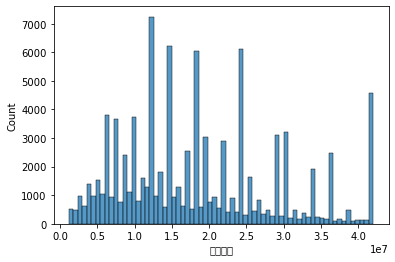

In [7]:
sns.histplot(train_df['대출금액'])

대출 금액은 다음과 같이 다양한 분포를 가지는데, 중요한 것은 등급과의 상관관계이다. 따라서 boxplot이 필요하다.

<AxesSubplot:xlabel='대출등급', ylabel='대출금액'>

C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 45824 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 52636 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 46321 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 44553 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 44552 missing from current font.
  font.set_text(s, 0.0, flags=flags)
C:\Users\USER\anaconda3\lib\site-packages\matplotlib\backends\backend_agg.py:238: RuntimeWarning: Glyph 50529 missing from current

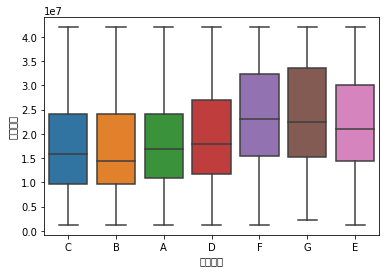

In [8]:
sns.boxplot(x = '대출등급', y = '대출금액', data = train_df)

등급에 따라 대출 금액의 차이는 크게 보이지 않는다.

### 근로기간

In [9]:
train_df['근로기간'].value_counts()

10+ years    31585
2 years       8450
< 1 year      7774
3 years       7581
1 year        6249
Unknown       5671
5 years       5665
4 years       5588
8 years       4888
6 years       3874
7 years       3814
9 years       3744
10+years       896
<1 year        370
3               89
1 years         56
Name: 근로기간, dtype: int64

통합이 필요한 변수들이 많이 보인다. 근데, 문제는 이것이 등급과 관련이 있는지에 대한 문제이다.

In [11]:
def work_year_check(s):
    if s in ['< 1 year', '<1 year', '< 1 years']:
        return 'under 1'
    elif s in ['10+years', '10+ years']:
        return 'over 10'
    elif s == 'Unknown':
        return 'Unknown'
    else:
        return str(s[0])

In [12]:
train_df['근로기간'] = train_df['근로기간'].apply(lambda x : work_year_check(x))
test_df['근로기간'] = test_df['근로기간'].apply(lambda x : work_year_check(x))

In [15]:
train_df['근로기간'].value_counts()

over 10    32481
2           8450
under 1     8144
3           7670
1           6305
Unknown     5671
5           5665
4           5588
8           4888
6           3874
7           3814
9           3744
Name: 근로기간, dtype: int64

잘 통일되었으나 다른 문제가 있다. 10년 이상 근무가 다른 범주형 변수 대비 유달리 많아 의미가 있을지가 의문이다.

In [17]:
pd.crosstab(index = train_df['근로기간'], columns = train_df['대출등급'])

대출등급,A,B,C,D,E,F,G
근로기간,,,,,,,
1,1031,1867,1860,927,481,110,29
2,1454,2493,2495,1107,695,170,36
3,1315,2302,2225,1028,608,153,39
4,969,1659,1577,796,440,122,25
5,986,1679,1646,736,475,119,24
6,650,1157,1124,543,296,85,19
7,619,1138,1103,535,318,79,22
8,867,1417,1364,707,385,128,20
9,621,1137,1049,545,289,85,18


In [19]:
from scipy.stats import chi2_contingency
data_df = pd.crosstab(index = train_df['근로기간'], columns = train_df['대출등급'])
chi2_contingency(data_df)

(150.23740713907418,
 1.6380144249775955e-08,
 66,
 array([[1098.1728872 , 1886.83806883, 1808.65905456,  874.37400046,
          481.51463227,  127.94120091,   27.50015577],
        [1471.77809625, 2528.75205101, 2423.97605251, 1171.84144391,
          645.32888861,  171.46758884,   36.85587887],
        [1335.92165659, 2295.32878476, 2200.22441689, 1063.67146447,
          585.76006812,  155.63981141,   33.45379774],
        [ 973.28946767, 1672.26822024, 1602.97966644,  774.94082705,
          426.75713959,  113.39182088,   24.37285812],
        [ 986.70093671, 1695.31128627, 1625.06796893,  785.61914553,
          432.63765136,  114.9543066 ,   24.70870459],
        [ 674.75365028, 1159.33555569, 1111.29979023,  537.24423121,
          295.85847509,   78.61129458,   16.89700293],
        [ 664.30315492, 1141.37991983, 1094.08812595,  528.92346356,
          291.27625813,   77.39377324,   16.63530438],
        [ 851.36702183, 1462.78580182, 1402.17691653,  677.86520448,
          37

In [20]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd
hsd = pairwise_tukeyhsd(train_df['대출등급'], train_df[''], alpha = 0.05)
hsd.summary()

TypeError: Cannot cast array data from dtype('O') to dtype('float64') according to the rule 'safe'